In [35]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings("ignore")

## Estrazione dati da MongoDB

In [36]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os

In [37]:
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(MONGO_URI)
db=client["PolymerPrediction"]
collection=db["biceranoTg"]
target="Tg"
#print(collection.count_documents({}))

In [38]:
docs = list(collection.find({}))
df = pd.DataFrame(docs)

# espando il dizionario "properties"
prop_df = pd.json_normalize(df["properties"])

# integro nel dataframe
df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

# rimuovo righe senza SMILES, Tg o densità o con SMILES malformato
df = df.dropna(subset=["smiles", target])
df = df[~df["smiles"].str.contains(r"\[\[", na=False)].copy()
df.describe()

,_id,polymer_name,smiles,bigsmiles,source_dataset,Tg,density,Tc,glass_cte,rubber_cte
0,698ddd4a8603d1724287a296,Poly[oxy(diethylsilylene)],[*]O[Si][*](CC)CC,{<O[Si](CC)(CC)>},biceranoTg,130,None,None,None,None
1,698ddd4a8603d1724287a297,Poly(dimethyl siloxane),[*]O[Si][*](C)C,{<O[Si](C)(C)>},biceranoTg,152,None,None,None,None
2,698ddd4a8603d1724287a298,"Poly(cis-1,4-butadiene)",[*]C/C=C\C[*],{$C/C=C\C$},biceranoTg,171,None,None,None,None
3,698ddd4a8603d1724287a299,Poly(dimethylsilylenemethylene),[*]C[Si][*](C)C,{<C[Si](C)(C)>},biceranoTg,173,None,None,None,None
4,698ddd4a8603d1724287a29a,Poly[oxy(methylphenylsilylene)],[*]O[Si][*](C)c1ccccc1,{<O[Si](c1ccccc1)(C)>},biceranoTg,187,None,None,None,None


## Integrazione descrittori RDKit

In [39]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np

descriptor_names = [desc[0] for desc in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
# print(descriptor_names)

def rdkit_descr(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return {d: np.nan for d in descriptor_names}
    values = calc.CalcDescriptors(mol)
    return dict(zip(descriptor_names, values))

desc_df = df["smiles"].apply(rdkit_descr).apply(pd.Series)
desc_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.374630,5.374630,0.277901,-1.277778,0.488677,15.666667,102.209,92.129,102.050091,36.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.192130,5.192130,0.293457,-1.157407,0.438406,17.500000,74.155,68.107,74.018791,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.354167,2.354167,0.681389,0.681389,0.418693,16.000000,54.092,48.044,54.046950,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.555818,2.555818,0.793457,-0.935185,0.430555,17.500000,72.183,64.119,72.039527,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.446909,5.446909,0.194793,-1.719444,0.563134,13.888889,136.226,128.162,136.034441,46.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


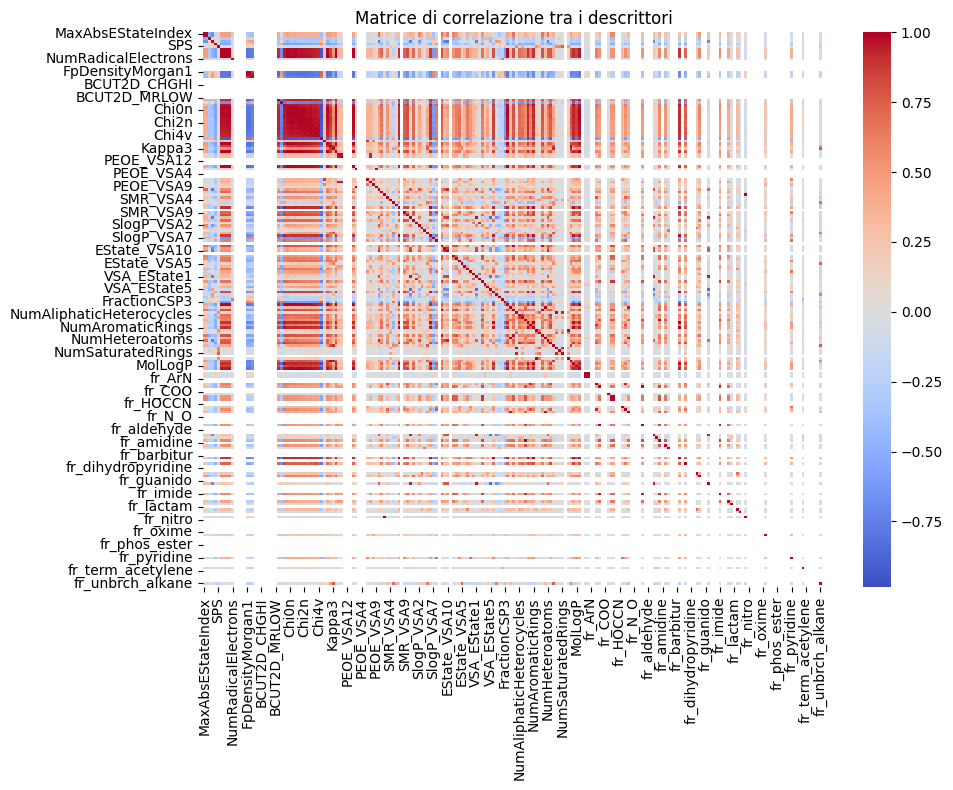

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = desc_df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra i descrittori")
plt.tight_layout()
plt.show()

## Aggiunta Fingerprint

In [41]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*1024
    fp = morgan_gen.GetFingerprint(mol)  
    return list(fp)

fp_df = df["smiles"].apply(morgan_fp).apply(pd.Series)
fp_df.columns = [f"fp_{i}" for i in range(fp_df.shape[1])]

In [42]:
from rdkit.Chem import MACCSkeys

def maccs_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*167  # MACCS ha 167 bit (indice 0 inutilizzato)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)
maccs_df = df["smiles"].apply(maccs_fp).apply(pd.Series)
maccs_df.columns=[f"maccs_{i}" for i in range(167)]

feature_df = pd.concat([desc_df, fp_df, maccs_df], axis=1)

## Pulizia dei dati

In [43]:
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
feature_df = feature_df.dropna(axis=1, how="all")

# rimuovo colonne costanti (con varianza 0) 
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.0)
sel.fit(feature_df)

mask = sel.get_support()
feature_df = feature_df.loc[:, mask]

print("Shape:", feature_df.shape[1])

Shape: 1027


## Preparazione dataset (separazione target)

In [44]:
y = df[target]
X = feature_df.copy()
X.index = df["_id"]
print("Shape X:", X.shape)
print("Shape y:", y.shape)
X.sample(10)

import numpy as np

X_np = np.ascontiguousarray(X.to_numpy(), dtype=np.float32)

print("dtype:", X_np.dtype)
print("contiguous:", X_np.flags['C_CONTIGUOUS'])
print("finite:", np.isfinite(X_np).all())
print("max abs:", np.max(np.abs(X_np)))


Shape X: (304, 1027)
Shape y: (304,)
dtype: float32
contiguous: True
finite: True
max abs: 109191590000000.0


## Gradient Boosting
Anche se le colonne sono ancora tante, per farsi un'idea

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

random_state=25

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

model_base = GradientBoostingRegressor(random_state=random_state)
model_base.fit(X_train, y_train)

pred_base = model_base.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_base))
print("R2:", r2_score(y_test, pred_base))


MAE: 26.798991060523864
R2: 0.8795171137194805


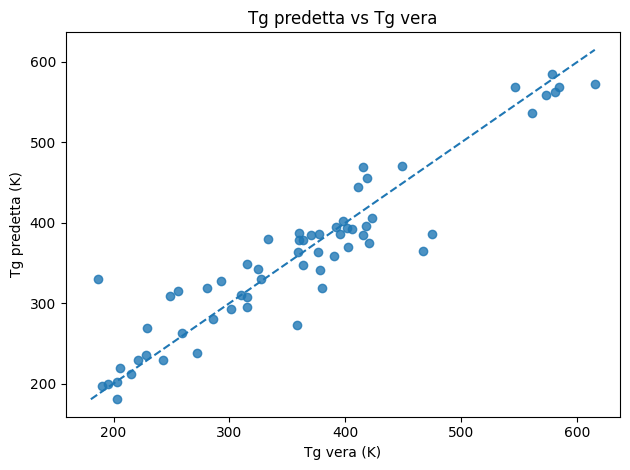

In [46]:
from matplotlib import pyplot as plt

plt.figure()
plt.scatter(y_test, pred_base, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred_base.min())
max_val = max(y_test.max(), pred_base.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel(f"{target} vera (K)")
plt.ylabel(f"{target} predetta (K)")
plt.title(f"{target} predetta vs {target} vera")

plt.tight_layout()
plt.show()

## Cross validation

Per la validazione incrociata uso 5-fold CV, poiché rappresenta il miglior compromesso tra stabilità della stima e quantità di dati utilizzata per l’addestramento. Con dataset piccoli e un numero elevato di feature (come in questo caso), un numero maggiore di fold aumenterebbe la varianza delle performance e renderebbe il modello più instabile. 

In [48]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb_model = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 800, 'subsample': 1.0}

Best CV MAE:
26.36568576745135

Performance on Test Set:
MAE: 23.62709833591177
R² : 0.9192275355151953


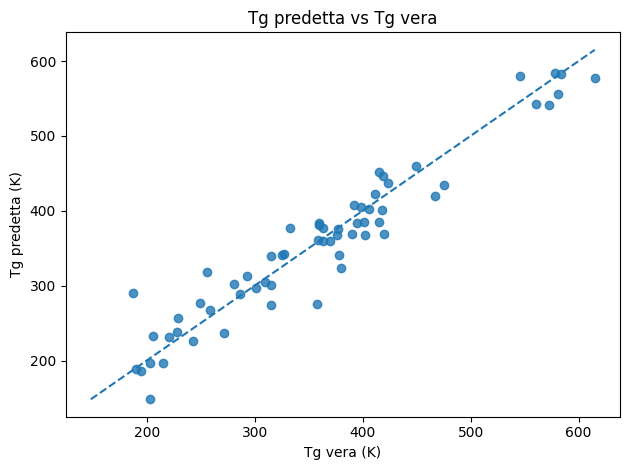

In [49]:

plt.figure()
plt.scatter(y_test, pred, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel(f"{target} vera (K)")
plt.ylabel(f"Tg predetta (K)")
plt.title(f"{target} predetta vs {target} vera")

plt.tight_layout()
plt.show()

## Feature selection

### Mutual Info Regression

In [50]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y, random_state=random_state)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# seleziono le top N feature
N = 300
top_features_mi = mi_series.head(N).index

X_mi_selected = X[top_features_mi]
print(X_mi_selected.shape)
print(X.shape)
print("Feature scelte (MI):", len(top_features_mi))

(304, 300)
(304, 1027)
Feature scelte (MI): 300


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_mi_selected, y, test_size=0.2, random_state=random_state
)

model_mi = GradientBoostingRegressor(random_state=random_state)
model_mi.fit(X_train, y_train)

pred_mi = model_mi.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_mi))
print("R²:", r2_score(y_test, pred_mi))


MAE: 25.91440731292007
R²: 0.8757170148885813


### Permutation importance
Uso il modello del passaggio precedente perché serve un modello già addestrato e abbastanza buono

In [52]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

perm = permutation_importance(model_mi, X_mi_selected, y, n_repeats=10, random_state=random_state)
perm_series = pd.Series(perm.importances_mean, index=X_mi_selected.columns)
perm_series = perm_series.sort_values(ascending=False)

thr = perm_series.mean()   
selected = perm_series[perm_series > thr].index

X_perm_selected = X_mi_selected[selected]

print("Feature scelte (Permutation Importance):", X_perm_selected.shape)


Feature scelte (Permutation Importance): (304, 27)


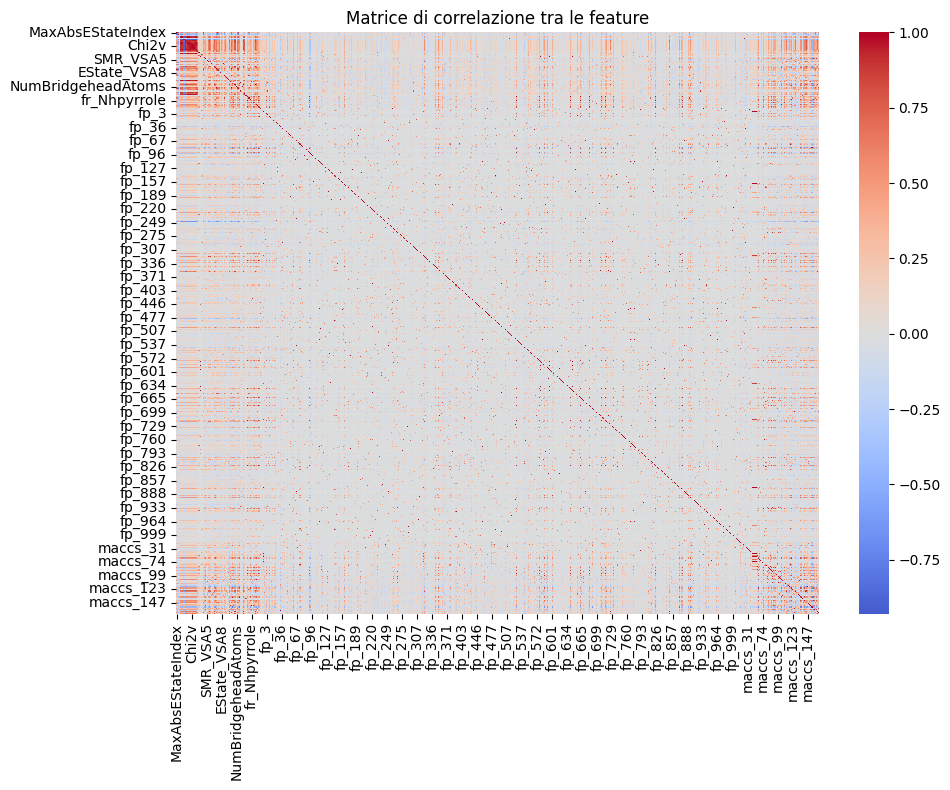

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = X.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra le feature")
plt.tight_layout()
plt.show()

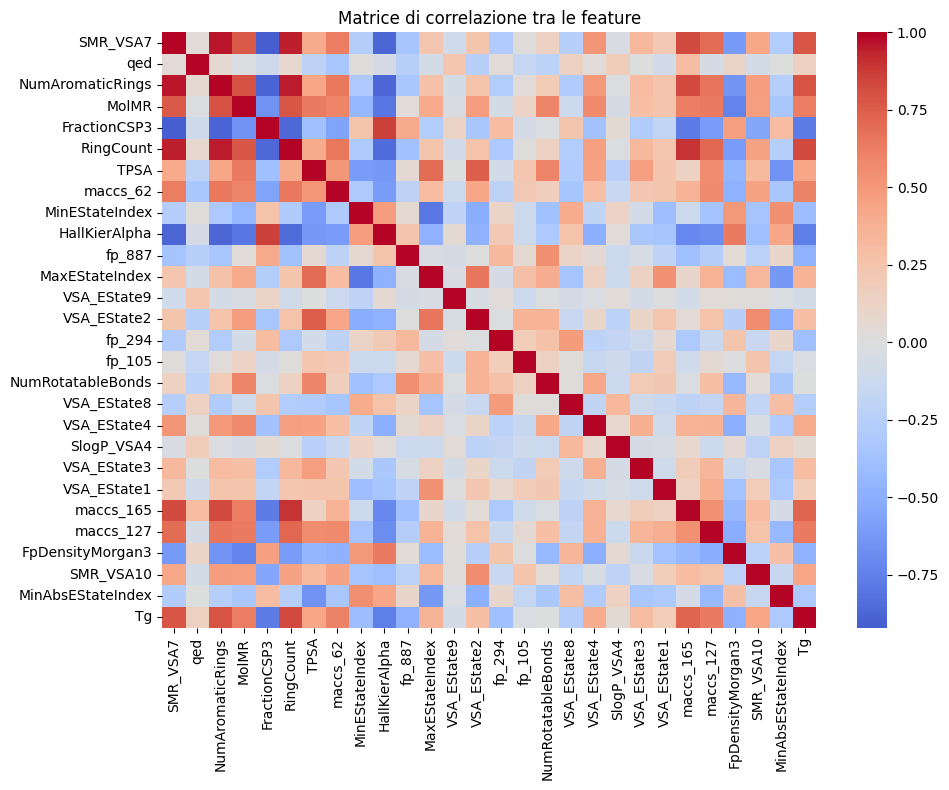

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

test=pd.concat([X_perm_selected.reset_index().drop(columns=["_id"]), pd.DataFrame(y)], axis=1)
corr = test.corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra le feature")
plt.tight_layout()
plt.show()

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_perm_selected, y, test_size=0.2, random_state=random_state
)

model_perm = GradientBoostingRegressor(random_state=random_state)
model_perm.fit(X_train, y_train)

pred_perm = model_perm.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_perm))
print("R²:", r2_score(y_test, pred_perm))


MAE: 28.083174923088123
R²: 0.8596818764490539


## Cross validation finale

In [56]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 800, 'subsample': 1.0}

Best CV MAE:
28.63225576488336

Performance on Test Set:
MAE: 30.111469157670914
R² : 0.856840020193423


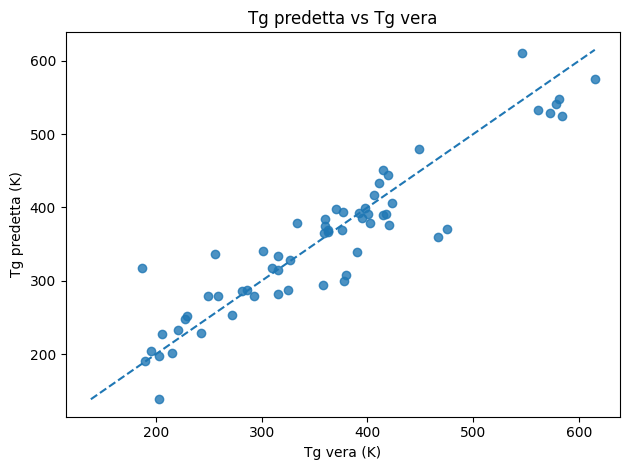

In [57]:

plt.figure()
plt.scatter(y_test, pred, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel(f"{target} vera (K)")
plt.ylabel(f"{target} predetta (K)")
plt.title(f"{target} predetta vs {target} vera")

plt.tight_layout()
plt.show()

### UMAP

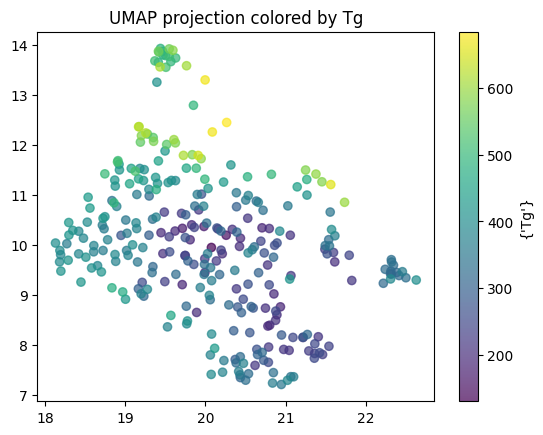

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.scatter(X_umap[:,0], X_umap[:,1], c=y, alpha=0.7)
plt.colorbar(label={target})
plt.title(f"UMAP projection colored by {target}")
plt.show()

In [64]:
from sklearn.cluster import KMeans

labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_umap)

In [67]:
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["cluster"] = labels
df_umap[target] = y.values

df_umap.groupby("cluster")[target].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,146.0,299.568493,74.260391,130.0,233.50,309.0,348.0,600.0
1,158.0,416.930380,116.857097,152.0,359.25,410.5,493.0,685.0


In [68]:
X_clustered = X.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

Ipc                    1.220430e+12
BertzCT                6.659624e+02
MolWt                  1.315009e+02
ExactMolWt             1.312953e+02
HeavyAtomMolWt         1.308193e+02
SMR_VSA7               6.111563e+01
LabuteASA              5.768076e+01
PEOE_VSA14             5.599240e+01
SlogP_VSA6             5.081126e+01
NumValenceElectrons    4.286561e+01
dtype: float64

In [69]:
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns,
    index=X.index
)
X_clustered = X_scaled.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

FractionCSP3    1.429228
fp_849          1.394685
fp_356          1.382036
maccs_162       1.368291
fp_726          1.305213
maccs_163       1.276737
maccs_165       1.241866
SMR_VSA7        1.173160
SlogP_VSA6      1.127150
maccs_128       1.119497
dtype: float64

### Univariate regression - Analisi dei descrittori (solo per esplorazione)

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

scores = []

for col in X.columns:
    X_col = X[[col]]  
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_col, y, test_size=0.2, random_state=random_state
    )
    
    model = RandomForestRegressor(n_estimators=200, random_state=random_state)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    scores.append({
        "feature": col,
        "MAE": mae,
        "R2": r2
    })

import pandas as pd
results = pd.DataFrame(scores)
results_sorted = results.sort_values("MAE")
results_sorted.head(20)

,feature,MAE,R2
29,HallKierAlpha,45.488663,0.717673
107,RingCount,46.231384,0.716148
60,SlogP_VSA6,47.633040,0.680697
30,Ipc,48.079946,0.652734
94,NumAromaticRings,48.509268,0.697374
84,FractionCSP3,51.161956,0.601014
56,SlogP_VSA2,51.342939,0.678836
50,SMR_VSA7,51.987965,0.653236
126,fr_benzene,52.865304,0.652786
92,NumAromaticCarbocycles,52.865304,0.652786


In [71]:
results.sort_values("R2", ascending=False).head(20)

,feature,MAE,R2
29,HallKierAlpha,45.488663,0.717673
107,RingCount,46.231384,0.716148
94,NumAromaticRings,48.509268,0.697374
60,SlogP_VSA6,47.633040,0.680697
56,SlogP_VSA2,51.342939,0.678836
50,SMR_VSA7,51.987965,0.653236
92,NumAromaticCarbocycles,52.865304,0.652786
126,fr_benzene,52.865304,0.652786
30,Ipc,48.079946,0.652734
16,BertzCT,53.946039,0.623101


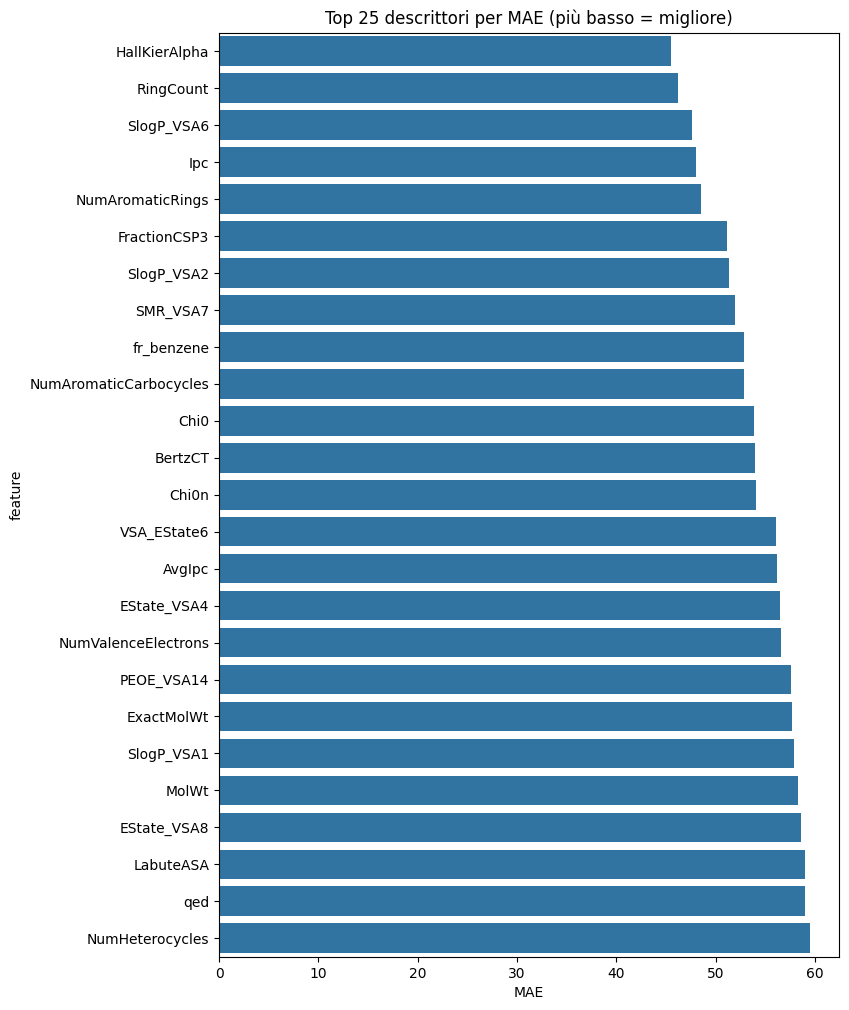

In [72]:

plt.figure(figsize=(8,12))
sns.barplot(data=results_sorted.head(25), x="MAE", y="feature")
plt.title("Top 25 descrittori per MAE (più basso = migliore)")
plt.show()
